In [2]:
import duckdb
import os
import pandas
import matplotlib.pyplot as plt
import polars as pl
import pandas as pd
from lifelines import KaplanMeierFitter
from lifelines import WeibullFitter
from lifelines import WeibullAFTFitter
from lifelines import LogNormalFitter
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
os.chdir("..")

In [4]:
df = pl.scan_parquet('data/mot_last_test.parquet').collect().to_pandas()

In [42]:
print(df['mileage'].mean())

119220.15755167387


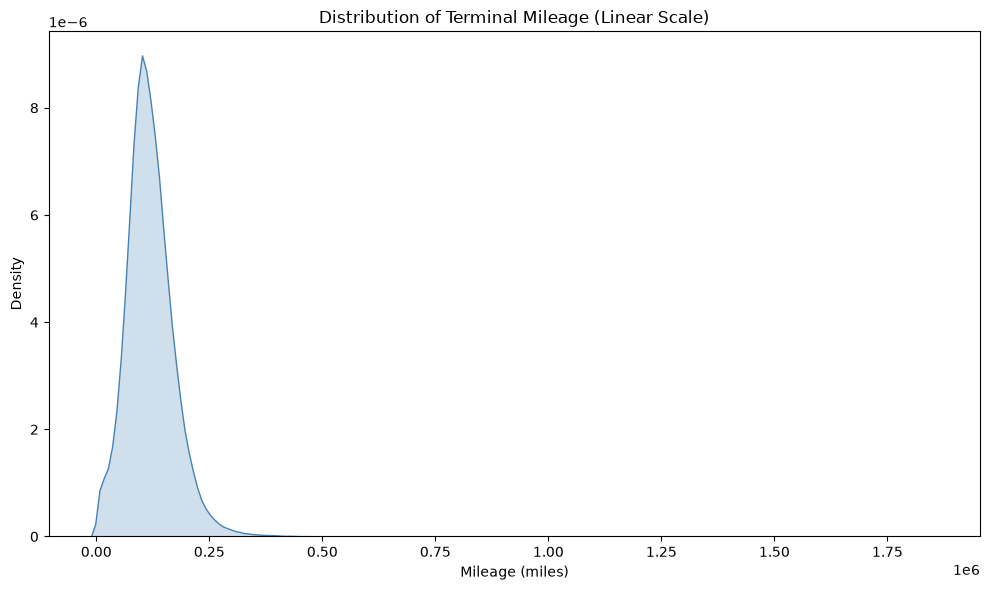

In [43]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="mileage", fill=True, color="steelblue")
plt.title("Distribution of Terminal Mileage (Linear Scale)")
plt.xlabel("Mileage (miles)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

In [94]:
kmf = KaplanMeierFitter()

kmf.fit(
    df['mileage_estimate'],
    event_observed=df['event_interval']
)

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 1.10354e+06 total observations, 508403 right-censored observations>

<Axes: xlabel='timeline'>

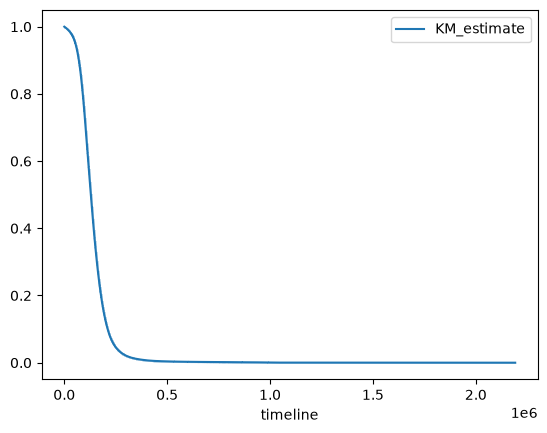

In [95]:
kmf.plot()

In [79]:
print(f"Median Survival Mileage: {kmf.median_survival_time_:.0f} miles")

Median Survival Mileage: 129171 miles


In [6]:
counts = df['make'].value_counts()

# 2. Identify makes with > 5000 entries
valid_makes = counts[counts > 1000].index

# 3. Filter the dataframe
df_sample = df[df['make'].isin(valid_makes)]
df_sample = df_sample.groupby('event').sample(frac=0.1, random_state=123)

In [166]:
lnf = LogNormalFitter()
lnf.fit(
    df_sample['mileage_estimate'],
    df_sample['event_interval']
)

<lifelines.LogNormalFitter:"LogNormal_estimate", fitted with 108747 total observations, 49874 right-censored observations>

<Axes: >

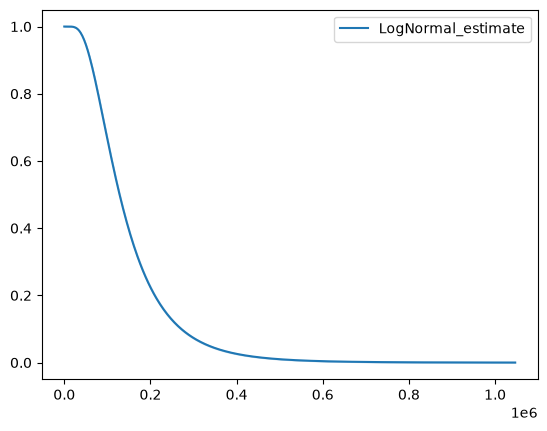

In [167]:
lnf.plot_survival_function()

In [168]:
print(f"Median Survival Mileage: {lnf.median_survival_time_:.0f} miles")

Median Survival Mileage: 128329 miles


In [7]:
wf = WeibullFitter()
wf.fit(
    df_sample['mileage_estimate'],
    df_sample['event_interval']
)

<lifelines.WeibullFitter:"Weibull_estimate", fitted with 108747 total observations, 49874 right-censored observations>

<Axes: >

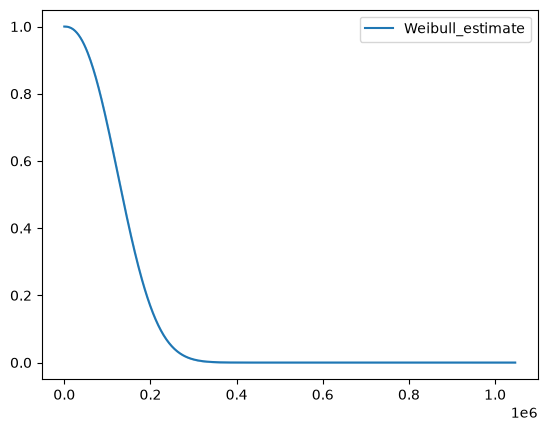

In [8]:
wf.plot_survival_function()

In [16]:
print(f"Median Survival Mileage: {wf.median_survival_time_:.0f} miles")

Median Survival Mileage: 134022 miles


In [17]:
print(wf.rho_)

2.370587107120227


In [172]:
print(wf.AIC_)
print(lnf.AIC_)

1487329.3704511067
1502144.4357879874


In [15]:
weibull_aft = WeibullAFTFitter()

weibull_aft.fit(
    df_sample,
    duration_col = 'mileage_estimate',
    event_col = 'event_interval',
    formula = 'engineSize_bucket:fuelType'
)

D:\DataScience\Portfolio\UK Car Analyser\.venv\Lib\site-packages\lifelines\fitters\__init__.py:2090: ApproximationWarning: The Hessian was not invertible. We will instead approximate it using the pseudo-inverse.

It's advisable to not trust the variances reported, and to be suspicious of the fitted parameters too.

Some ways to possible ways fix this:

0. Are there any lifelines warnings outputted during the `fit`?
1. Does a particularly large variable need to be centered to 0?
2. Inspect your DataFrame: does everything look as expected? Do you need to add/drop a constant (intercept) column?
3. Is there high-collinearity in the dataset? Try using the variance inflation factor (VIF) to find redundant variables.
4. Trying adding a small penalizer (or changing it, if already present). Example: `WeibullAFTFitter(penalizer=0.01).fit(...)`.
5. Are there any extreme outliers? Try modeling them or dropping them to see if it helps convergence.

  warnings.warn(warning_text, exceptions.Approxima

<lifelines.WeibullAFTFitter: fitted with 108747 total observations, 49874 right-censored observations>

In [10]:
lambda_coeffs = weibull_aft.summary.loc['lambda_']['coef']

In [11]:
sorted_coeffs = lambda_coeffs.sort_values(ascending=False)

In [183]:
sorted_coeffs.head(5)

covariate
Intercept                             11.758214
engineSize_bucket[T.Electric]          0.612491
engineSize_bucket[T.2000.0-2499.0]     0.409458
engineSize_bucket[T.2500.0-2999.0]     0.337301
engineSize_bucket[T.4000.0-4499.0]     0.280238
Name: coef, dtype: float64

In [184]:
sorted_coeffs.tail(5)

covariate
engineSize_bucket[T.3500.0-3999.0]    0.117578
engineSize_bucket[T.5000.0-5499.0]    0.004325
engineSize_bucket[T.6000.0-6499.0]   -0.025626
engineSize_bucket[T.6500.0-6999.0]   -0.052042
engineSize_bucket[T.5500.0-5999.0]   -0.323860
Name: coef, dtype: float64

In [185]:
print(sorted_coeffs)

covariate
Intercept                             11.758214
engineSize_bucket[T.Electric]          0.612491
engineSize_bucket[T.2000.0-2499.0]     0.409458
engineSize_bucket[T.2500.0-2999.0]     0.337301
engineSize_bucket[T.4000.0-4499.0]     0.280238
engineSize_bucket[T.<1000]             0.250039
engineSize_bucket[T.3000.0-3499.0]     0.227727
engineSize_bucket[T.1500.0-1999.0]     0.222425
engineSize_bucket[T.4500.0-4999.0]     0.164326
engineSize_bucket[T.3500.0-3999.0]     0.117578
engineSize_bucket[T.5000.0-5499.0]     0.004325
engineSize_bucket[T.6000.0-6499.0]    -0.025626
engineSize_bucket[T.6500.0-6999.0]    -0.052042
engineSize_bucket[T.5500.0-5999.0]    -0.323860
Name: coef, dtype: float64


In [15]:
con.execute("""
SELECT min(first_use_date) FROM read_parquet('data/mot_data_combined.parquet')
           WHERE first_use_date<'1960-01-01'

""").df()

,min(first_use_date)
0,1-01-01


In [58]:
del df